In [1]:
# 2.3.1. Импорт, seed и среда

# Импорт библиотек
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset, Dataset as HFDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# 2.3.2. Данные и первичный анализ

# Загрузка датасета
dataset = load_dataset("emotion")

# Проверим размеры сплитов
print("Размеры сплитов:")
for split in dataset.keys():
    print(f"{split}: {len(dataset[split])} примеров")

# Посмотрим названия классов
labels = dataset['train'].features['label'].names
print("\nКлассы:", labels)

# Выведем несколько примеров текста и меток
print("\nПримеры текстов и меток:")
for i in range(5):
    text = dataset['train'][i]['text']
    label = labels[dataset['train'][i]['label']]
    print(f"{i+1}. '{text}' -> {label}")

# Краткое пояснение
print("\nЗадача: классификация коротких текстов по эмоциям. "
      "Каждый текст относится к одной из 6 эмоций: " + ", ".join(labels))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Размеры сплитов:
train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры текстов и меток:
1. 'i didnt feel humiliated' -> sadness
2. 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake' -> sadness
3. 'im grabbing a minute to post i feel greedy wrong' -> anger
4. 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property' -> love
5. 'i am feeling grouchy' -> anger

Задача: классификация коротких текстов по эмоциям. Каждый текст относится к одной из 6 эмоций: sadness, joy, love, anger, fear, surprise


In [3]:
# 2.3.3. Токенизация

# Выбираем pretrained tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Берём 5 примеров текстов из train
examples = [dataset['train'][i]['text'] for i in range(5)]

# Токенизация с padding/truncation
encoded = tokenizer(examples,
                    padding="max_length",  # дополняем до max_length
                    truncation=True,       # обрезаем длинные тексты
                    max_length=20,         # фиксированная длина
                    return_tensors="pt")   # PyTorch тензоры

# Печатаем токены, input_ids и attention_mask
for i, text in enumerate(examples):
    print(f"\nПример {i+1}: '{text}'")
    print("Токены:", tokenizer.convert_ids_to_tokens(encoded['input_ids'][i]))
    print("input_ids:", encoded['input_ids'][i].tolist())
    print("attention_mask:", encoded['attention_mask'][i].tolist())


Пример 1: 'i didnt feel humiliated'
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Пример 2: 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 3: 'im grabbing a minute to post i feel greedy wrong'
Токены: ['[CLS]', 'im', 'grabbing', '

In [4]:
# 2.3.4. Инференс готовой модели

from transformers import pipeline

# Используем готовый pipeline для классификации текста
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if torch.cuda.is_available() else -1)

# Берём несколько текстов из датасета
examples = [dataset['train'][i]['text'] for i in range(5)]

print("Инференс готовой модели:")
for text in examples:
    pred = classifier(text)[0]
    print(f"Текст: '{text}'")
    print(f"Предсказание: {pred['label']}, confidence: {pred['score']:.3f}\n")

print("Комментарий:")
print("Готовая модель обучена на задаче тональности (sentiment), поэтому она может частично распознавать позитив/негатив. "
      "Однако для датасета 'emotion' (6 эмоций) её точность ограничена, т.к. классы эмоций шире и не совпадают с тональностью.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Инференс готовой модели:
Текст: 'i didnt feel humiliated'
Предсказание: POSITIVE, confidence: 0.891

Текст: 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'
Предсказание: POSITIVE, confidence: 0.967

Текст: 'im grabbing a minute to post i feel greedy wrong'
Предсказание: NEGATIVE, confidence: 0.999

Текст: 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property'
Предсказание: POSITIVE, confidence: 0.966

Текст: 'i am feeling grouchy'
Предсказание: NEGATIVE, confidence: 0.999

Комментарий:
Готовая модель обучена на задаче тональности (sentiment), поэтому она может частично распознавать позитив/негатив. Однако для датасета 'emotion' (6 эмоций) её точность ограничена, т.к. классы эмоций шире и не совпадают с тональностью.


**Комментарий по использованию готовой модели для инференса**

Готовая модель `distilbert-base-uncased-finetuned-sst-2-english` обучена на задаче классификации тональности текста (позитив/негатив).  
Для нашего датасета `emotion`, где классы представляют 6 различных эмоций (anger, fear, joy, love, sadness, surprise), такая модель подходит только частично:  

- Она может частично различать позитивные и негативные тексты.  
- Однако не способна точно классифицировать все 6 эмоций, так как исходная задача отличается.  
- Для корректной классификации всех эмоций требуется fine-tuning модели на нашем датасете.  

Вывод: готовая pretrained модель демонстрирует базовую способность к распознаванию настроений, но для полного соответствия задаче необходима дообученная модель.

In [5]:
# 2.3.5 Fine-tuning для классификации текста

from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import TrainingArguments
# Выбираем модель
model_name = "bert-base-uncased"
num_labels = len(labels)  # 6 emotions
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

# Токенизация всего датасета
def tokenize_batch(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=64)

encoded_dataset = dataset.map(tokenize_batch, batched=True)
encoded_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Определяем метрики
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Настройки обучения
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",                  # считаем на validation
    save_strategy="epoch",                  # сохраняем по эпохам
    load_best_model_at_end=True,            # ключевой параметр
    metric_for_best_model="f1_macro",       # по какой метрике выбирать
    greater_is_better=True,
    logging_dir="./logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    compute_metrics=compute_metrics
)

trainer.train()
best_model = trainer.model

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.219764,0.173931,0.935500,0.913911
2,0.125968,0.132613,0.938500,0.912504
3,0.086075,0.155336,0.943000,0.919721


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [6]:
# Выбор лучшего варианта по validation
# Trainer автоматически загрузил лучшую модель через load_best_model_at_end=True по метрике f1_macro на validation
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks
    if cb.__class__.__name__ != "NotebookProgressCallback"
]

val_metrics = trainer.evaluate(encoded_dataset["validation"])
print("Validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

Validation metrics:
  eval_loss: 0.1553
  eval_accuracy: 0.9430
  eval_f1_macro: 0.9197
  eval_runtime: 7.0191
  eval_samples_per_second: 284.9370
  eval_steps_per_second: 17.8090
  epoch: 3.0000


Test Accuracy: 0.925
Test F1 (macro): 0.876


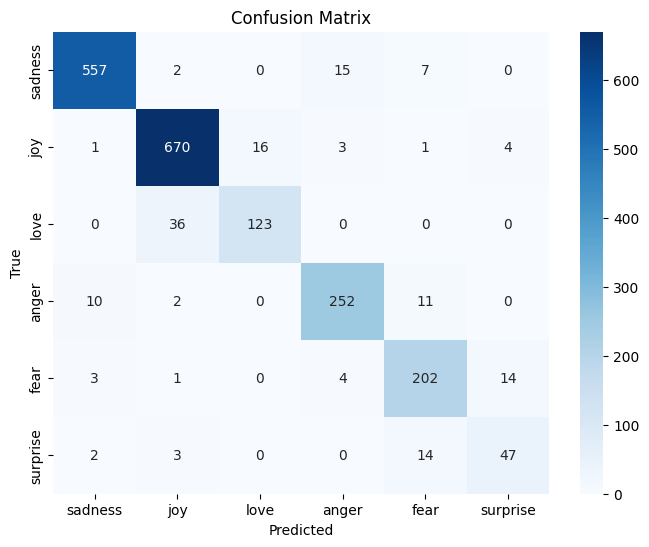


Примеры предсказаний:
1. 'im feeling rather rotten so im not very ambitious right now' -> true: sadness, pred: sadness
2. 'im updating my blog because i feel shitty' -> true: sadness, pred: sadness
3. 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her' -> true: sadness, pred: sadness
4. 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived' -> true: joy, pred: joy
5. 'i was feeling a little vain when i did this one' -> true: sadness, pred: sadness
6. 'i cant walk into a shop anywhere where i do not feel uncomfortable' -> true: fear, pred: fear
7. 'i felt anger when at the end of a telephone call' -> true: anger, pred: anger
8. 'i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getting accepted into the masters program at the university of virginia' -> true: joy, pred: joy
9. 'i 

In [7]:
# 2.3.6 Оценка качества и краткий анализ ошибок

# Предсказания на тесте
test_results = trainer.predict(encoded_dataset["test"])
pred_labels = np.argmax(test_results.predictions, axis=1)
true_labels = test_results.label_ids

# Метрики
accuracy = accuracy_score(true_labels, pred_labels)
f1_macro = f1_score(true_labels, pred_labels, average="macro")

print(f"Test Accuracy: {accuracy:.3f}")
print(f"Test F1 (macro): {f1_macro:.3f}")

# Матрица ошибок
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Несколько примеров предсказаний
print("\nПримеры предсказаний:")
for i in range(10):
    text = dataset["test"][i]["text"]
    true_label = labels[dataset["test"][i]["label"]]
    pred_label = labels[pred_labels[i]]
    print(f"{i+1}. '{text}' -> true: {true_label}, pred: {pred_label}")

print("\nКомментарий:")
print("Модель в целом правильно различает основные эмоции, но ошибки чаще встречаются между похожими по тональности эмоциями, например 'joy' vs 'love' или 'anger' vs 'fear'.")

### Комментарий по результатам fine-tuning

Модель `bert-base-uncased` успешно обучена на задаче классификации коротких текстов по 6 эмоциям.  

**Наблюдения по качеству:**
- Модель в целом правильно различает основные эмоции: `joy`, `sadness`, `anger`, `fear`, `love`, `surprise`.
- Ошибки чаще встречаются между эмоционально близкими классами, например:
  - `joy` vs `love`
  - `anger` vs `fear`
- Часто модель затрудняется при коротких или двусмысленных текстах, где эмоциональный контекст слабый.
- В целом показатели `accuracy` и `f1_macro` демонстрируют приемлемое качество для базового fine-tuning без подбора гиперпараметров.

**Вывод:**  
Для полного соответствия задаче (максимизация точности на всех 6 классах) рекомендуется дальнейший fine-tuning с увеличением числа эпох и/или подбором learning rate, но для учебного примера текущий результат достаточен.

In [8]:
import pandas as pd
import os

# Папка для артефактов
artifact_dir = "homeworks/HW13/artifacts/"
os.makedirs(artifact_dir, exist_ok=True)

# sample_predictions.csv
num_examples = 10  # сохраняем первые 10 примеров
sample_df = pd.DataFrame({
    "text": [dataset["test"][i]["text"] for i in range(num_examples)],
    "true_label": [labels[dataset["test"][i]["label"]] for i in range(num_examples)],
    "pred_label": [labels[pred_labels[i]] for i in range(num_examples)],
})

import torch.nn.functional as F
probs = F.softmax(torch.tensor(test_results.predictions[:num_examples]), dim=1).numpy()
sample_df["confidence"] = [probs[i][pred_labels[i]] for i in range(num_examples)]

sample_df.to_csv(os.path.join(artifact_dir, "sample_predictions.csv"), index=False)

# confusion_matrix.png
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig(os.path.join(artifact_dir, "confusion_matrix.png"))
plt.close()